# Mantle Gemma (and other OOS models) Performance And Accuracy

This notebook benchmarks Mantle OpenAI-compatible model endpoints and records both latency/throughput and answer quality. It uses `scripts/mantle_gemma_benchmark.py`, so notebook runs and headless CLI runs write the same CSV outputs under `results/mantle_gemma/`.

The first sections load credentials, choose a workload profile, optionally prepare standard accuracy datasets, and run one or more benchmark iterations. Later sections reload the generated CSVs, summarize metrics, plot distributions, and inspect wrong accuracy answers.


## Imports


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import os
import re
import shlex
import sys

PROJECT = Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
SCRIPTS = PROJECT / "scripts"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

import mantle_gemma_benchmark as mgb


## Configuration

These cells keep credentials, workload size, and accuracy dataset selection in one place. The token loader reads a literal `BEDROCK_MANTLE_TOKEN` assignment from `~/.zshrc` first, then common fallback startup files when the variable is not already present in Python's environment; it does not print the secret value.


### Credentials

Jupyter `!source ~/.zshrc` runs in a child shell and does not update `os.environ`. This cell reads startup files directly, extracts a literal token assignment, and copies it into the Python process used by the benchmark runner. Set `MANTLE_TOKEN_FILE` before this cell if the token lives in a different file.


In [2]:
TOKEN_ENV = "BEDROCK_MANTLE_TOKEN"
TOKEN_FILE_OVERRIDE_ENV = "MANTLE_TOKEN_FILE"
TOKEN_SHELL_FILES = [Path.home() / ".zshrc", Path.home() / ".bashrc", Path.home() / ".profile"]
if os.environ.get(TOKEN_FILE_OVERRIDE_ENV):
    TOKEN_SHELL_FILES.insert(0, Path(os.environ[TOKEN_FILE_OVERRIDE_ENV]).expanduser())

seen_token_files = set()
TOKEN_SHELL_FILES = [
    path
    for path in TOKEN_SHELL_FILES
    if not (str(path) in seen_token_files or seen_token_files.add(str(path)))
]


def read_shell_assignment(name, path):
    path = Path(path).expanduser()
    if not path.exists():
        return None
    for line_no, raw_line in enumerate(path.read_text(encoding="utf-8", errors="replace").splitlines(), start=1):
        line = raw_line.strip()
        if not line or line.startswith("#") or name not in line:
            continue
        try:
            parts = shlex.split(line, comments=True, posix=True)
        except ValueError:
            continue
        if not parts:
            continue
        if parts[0] == "export":
            assignments = parts[1:]
        elif parts[0] in {"typeset", "declare"}:
            assignments = [part for part in parts[1:] if "=" in part]
        else:
            assignments = parts
        for part in assignments:
            if not part.startswith(f"{name}="):
                continue
            value = part.split("=", 1)[1]
            if value.startswith(("$", "`")):
                raise RuntimeError(
                    f"{path}:{line_no} defines {name} through shell expansion. "
                    "Export it before starting Jupyter or replace it with a literal assignment."
                )
            return value, path
    return None


token_source = "environment" if os.environ.get(TOKEN_ENV) else None
if not token_source:
    for shell_file in TOKEN_SHELL_FILES:
        result = read_shell_assignment(TOKEN_ENV, shell_file)
        if result:
            token, token_path = result
            os.environ[TOKEN_ENV] = token
            token_source = str(token_path)
            break

if not os.environ.get(TOKEN_ENV):
    looked = ", ".join(str(path) for path in TOKEN_SHELL_FILES)
    raise RuntimeError(
        f"Set {TOKEN_ENV} in the environment or as a literal assignment in one of: {looked}. "
        f"If it lives elsewhere, set {TOKEN_FILE_OVERRIDE_ENV} to that file path before running this cell."
    )

print(f"{TOKEN_ENV} loaded from {token_source}; value is not displayed.")


BEDROCK_MANTLE_TOKEN loaded from environment; value is not displayed.


### Workload Profile

`PROFILE` selects a notebook preset. The preset maps to one of the runner's base profiles and can also set request count, concurrency, input token load, output token load, and iteration count. Leave an override as `None` to use the preset value or the runner default.


In [3]:
# MODELS = ["google.gemma-4-31b", "google.gemma-4-26b-a4b"]
MODELS = ["google.gemma-4-31b", "openai.gpt-oss-120b"]
REGION = "us-west-2"
REGION = os.environ.get("AWS_REGION") or os.environ.get("AWS_DEFAULT_REGION") or REGION
# MANTLE_GEMMA_BASE_URL overrides; otherwise derive the endpoint root from REGION.
# BEDROCK_MANTLE_URL is intentionally ignored here because it is a machine-global
# default that may point at a different region. The runner picks the chat route
# per model: google.gemma-4* -> /openai/v1, all other models -> /v1.
BASE_URL = os.environ.get("MANTLE_GEMMA_BASE_URL") or f"https://bedrock-mantle.{REGION}.api.aws"
OUT_DIR = "results/mantle_gemma"
RUN_ID_PREFIX = ""
LIST_MODELS = True
INCLUDE_VISION = False

PROFILE_PRESETS = {
    "smoke": {
        "runner_profile": "smoke",
        "num_prompts": None,
        "max_concurrency": None,
        "input_tokens": None,
        "output_tokens": None,
        "description": "Cheap API and plotting check.",
    },
    "quick-text": {
        "runner_profile": "sglang-text",
        "num_prompts": 8,
        "max_concurrency": 2,
        "input_tokens": 256,
        "output_tokens": 128,
        "description": "Small text-only run with nontrivial prompt load.",
    },
    "latency-1k": {
        "runner_profile": "sglang-text",
        "num_prompts": 10,
        "max_concurrency": 1,
        "input_tokens": 1024,
        "output_tokens": 256,
        "description": "Single-concurrency latency probe with 1k-token synthetic inputs.",
    },
    "load-small": {
        "runner_profile": "sglang-text",
        "num_prompts": 32,
        "max_concurrency": 8,
        "input_tokens": 512,
        "output_tokens": 256,
        "description": "Small load test for request and token throughput.",
    },
    "load-medium": {
        "runner_profile": "sglang-text",
        "num_prompts": 100,
        "max_concurrency": 25,
        "input_tokens": 1024,
        "output_tokens": 512,
        "description": "Moderate load test; verify quota and cost before running.",
    },
    "load-large": {
        "runner_profile": "sglang-text",
        "num_prompts": 1000,
        "max_concurrency": 100,
        "input_tokens": 1024,
        "output_tokens": 1024,
        "description": "Full text throughput shape matching the SGLang benchmark.",
    },
    "sglang-text": {
        "runner_profile": "sglang-text",
        "num_prompts": None,
        "max_concurrency": None,
        "input_tokens": None,
        "output_tokens": None,
        "description": "Runner default text latency and throughput workloads.",
    },
    "sglang-full": {
        "runner_profile": "sglang-full",
        "num_prompts": None,
        "max_concurrency": None,
        "input_tokens": None,
        "output_tokens": None,
        "description": "Runner default text plus two-image vision workloads.",
    },
}

PROFILE = "latency-1k"
ITERATIONS = 1

# Explicit overrides. Set any of these to an integer/string to override the selected preset.
NUM_PROMPTS = None
MAX_CONCURRENCY = None
INPUT_TOKENS = None
OUTPUT_TOKENS = None
IMAGE_RESOLUTION = None

SKIP_PERFORMANCE = False
SKIP_ACCURACY = False
# Reasoning models (e.g. openai.gpt-oss-*) spend tokens on hidden reasoning before
# the final answer; small budgets truncate them mid-reasoning with empty content.
ACCURACY_MAX_TOKENS = 256
ACCURACY_CONCURRENCY = 4
TEMPERATURE = 0.0
TIMEOUT = 600.0
MAX_RETRIES = 0
SEED = 17

# Optional standard accuracy data. Disabled by default to avoid surprise downloads/API cost.
ENABLE_STANDARD_ACCURACY = False
STANDARD_ACCURACY_LIMITS = {
    "mmlu": 25,
    "gsm8k": 25,
    "arc_challenge": 25,
    "hellaswag": 25,
}
STANDARD_ACCURACY_JSONL = str(Path(OUT_DIR) / "standard_accuracy_sample.jsonl")

if PROFILE not in PROFILE_PRESETS:
    raise ValueError(f"Unknown PROFILE {PROFILE!r}. Options: {sorted(PROFILE_PRESETS)}")
if ITERATIONS < 1:
    raise ValueError("ITERATIONS must be at least 1.")

preset = PROFILE_PRESETS[PROFILE]
profile_config = {
    "profile": PROFILE,
    "runner_profile": preset["runner_profile"],
    "description": preset["description"],
    "models": MODELS,
    "region": REGION,
    "base_url": BASE_URL or f"derived from region {REGION}",
    "include_vision": INCLUDE_VISION,
    "iterations": ITERATIONS,
    "num_prompts": NUM_PROMPTS if NUM_PROMPTS is not None else preset.get("num_prompts"),
    "max_concurrency": MAX_CONCURRENCY if MAX_CONCURRENCY is not None else preset.get("max_concurrency"),
    "input_tokens": INPUT_TOKENS if INPUT_TOKENS is not None else preset.get("input_tokens"),
    "output_tokens": OUTPUT_TOKENS if OUTPUT_TOKENS is not None else preset.get("output_tokens"),
    "image_resolution": IMAGE_RESOLUTION,
    "accuracy_concurrency": ACCURACY_CONCURRENCY,
    "standard_accuracy_enabled": ENABLE_STANDARD_ACCURACY,
}

print("Resolved benchmark configuration:")
print(json.dumps({key: value for key, value in profile_config.items() if value is not None}, indent=2))

Resolved benchmark configuration:
{
  "profile": "latency-1k",
  "runner_profile": "sglang-text",
  "description": "Single-concurrency latency probe with 1k-token synthetic inputs.",
  "models": [
    "google.gemma-4-31b",
    "openai.gpt-oss-120b"
  ],
  "region": "us-east-2",
  "base_url": "https://bedrock-mantle.us-east-2.api.aws",
  "include_vision": false,
  "iterations": 1,
  "num_prompts": 10,
  "max_concurrency": 1,
  "input_tokens": 1024,
  "output_tokens": 256,
  "accuracy_concurrency": 4,
  "standard_accuracy_enabled": false
}


In [4]:
BASE_URL

'https://bedrock-mantle.us-east-2.api.aws'

## Optional Standard Accuracy Datasets

The runner always includes built-in `mini_gsm8k` and `mini_mmlu` probes. Enable this cell to sample standard datasets into the runner's JSONL format: MMLU, ARC-Challenge, and HellaSwag use multiple-choice exact match, while GSM8K uses final-number exact match. Keep limits small because every item is one API request per model.


In [5]:
ACCURACY_JSONL = ""


def choice_letter(index):
    return chr(ord("A") + int(index))


def normalize_choice_answer(answer, choices_count):
    if isinstance(answer, int):
        return choice_letter(answer)
    text = str(answer).strip().upper()
    if text.isdigit():
        value = int(text)
        if 0 <= value < choices_count:
            return choice_letter(value)
        if 1 <= value <= choices_count:
            return choice_letter(value - 1)
    return text[:1]


def limited_dataset(dataset, limit, seed):
    if limit is None:
        return dataset
    if hasattr(dataset, "shuffle"):
        dataset = dataset.shuffle(seed=seed)
    count = min(int(limit), len(dataset))
    return dataset.select(range(count))


def load_dataset_with_candidates(candidates, split):
    try:
        from datasets import load_dataset
    except ImportError as exc:
        raise RuntimeError("Install the optional dependency with `pip install datasets`.") from exc

    errors = []
    for candidate in candidates:
        dataset_name = candidate[0]
        config_name = candidate[1] if len(candidate) > 1 else None
        try:
            if config_name:
                return load_dataset(dataset_name, config_name, split=split)
            return load_dataset(dataset_name, split=split)
        except Exception as exc:
            label = f"{dataset_name}/{config_name}" if config_name else dataset_name
            errors.append(f"{label}: {exc}")
    raise RuntimeError("; ".join(errors))


def make_choice_map(values):
    return {choice_letter(index): str(value) for index, value in enumerate(values)}


def mmlu_rows(limit):
    dataset = load_dataset_with_candidates([("cais/mmlu", "all")], "test")
    rows = []
    for index, row in enumerate(limited_dataset(dataset, limit, SEED)):
        choices = row.get("choices") or [row.get(key) for key in ["A", "B", "C", "D"] if row.get(key) is not None]
        choices = [str(choice) for choice in choices]
        rows.append(
            {
                "suite": "mmlu",
                "id": str(row.get("id", f"mmlu_{index:05d}")),
                "category": str(row.get("subject") or row.get("category") or "mmlu"),
                "question": str(row.get("question") or row.get("input") or ""),
                "choices": make_choice_map(choices),
                "answer": normalize_choice_answer(row.get("answer"), len(choices)),
                "answer_type": "choice",
            }
        )
    return rows


def gsm8k_rows(limit):
    dataset = load_dataset_with_candidates([("openai/gsm8k", "main"), ("gsm8k", "main")], "test")
    rows = []
    for index, row in enumerate(limited_dataset(dataset, limit, SEED)):
        answer_text = str(row.get("answer", ""))
        match = re.search(r"####\s*(-?[\d,]+(?:\.\d+)?)", answer_text)
        answer = match.group(1).replace(",", "") if match else mgb.extract_number(answer_text)
        rows.append(
            {
                "suite": "gsm8k",
                "id": str(row.get("id", f"gsm8k_{index:05d}")),
                "category": "grade_school_math",
                "question": str(row.get("question") or row.get("problem") or ""),
                "answer": answer,
                "answer_type": "numeric",
            }
        )
    return rows


def arc_challenge_rows(limit):
    dataset = load_dataset_with_candidates([("allenai/ai2_arc", "ARC-Challenge"), ("ai2_arc", "ARC-Challenge")], "test")
    rows = []
    for index, row in enumerate(limited_dataset(dataset, limit, SEED)):
        raw_choices = row.get("choices") or {}
        texts = raw_choices.get("text", []) if isinstance(raw_choices, dict) else []
        labels = raw_choices.get("label", []) if isinstance(raw_choices, dict) else []
        choices = {}
        label_to_choice = {}
        for pos, text in enumerate(texts):
            label = str(labels[pos]).strip().upper() if pos < len(labels) else choice_letter(pos)
            canonical = label if len(label) == 1 and label.isalpha() else choice_letter(pos)
            choices[canonical] = str(text)
            label_to_choice[label] = canonical
        answer_key = str(row.get("answerKey") or row.get("answer") or "").strip().upper()
        rows.append(
            {
                "suite": "arc_challenge",
                "id": str(row.get("id", f"arc_challenge_{index:05d}")),
                "category": "science_reasoning",
                "question": str(row.get("question") or ""),
                "choices": choices,
                "answer": label_to_choice.get(answer_key, answer_key),
                "answer_type": "choice",
            }
        )
    return rows


def hellaswag_rows(limit):
    dataset = load_dataset_with_candidates([("Rowan/hellaswag",)], "validation")
    rows = []
    for index, row in enumerate(limited_dataset(dataset, limit, SEED)):
        endings = [str(value) for value in row.get("endings", [])]
        context = " ".join(str(row.get(key, "")).strip() for key in ["ctx_a", "ctx_b"]).strip()
        if not context:
            context = str(row.get("ctx", ""))
        rows.append(
            {
                "suite": "hellaswag",
                "id": str(row.get("ind", row.get("id", f"hellaswag_{index:05d}"))),
                "category": str(row.get("activity_label") or "commonsense_completion"),
                "question": f"{context}\nWhich ending is most plausible?",
                "choices": make_choice_map(endings),
                "answer": normalize_choice_answer(row.get("label"), len(endings)),
                "answer_type": "choice",
            }
        )
    return rows


if ENABLE_STANDARD_ACCURACY:
    builders = {
        "mmlu": mmlu_rows,
        "gsm8k": gsm8k_rows,
        "arc_challenge": arc_challenge_rows,
        "hellaswag": hellaswag_rows,
    }
    standard_rows = []
    for suite, limit in STANDARD_ACCURACY_LIMITS.items():
        if not limit:
            print(f"{suite}: skipped by limit={limit}")
            continue
        try:
            rows = builders[suite](limit)
        except Exception as exc:
            print(f"{suite}: skipped ({exc})")
            continue
        print(f"{suite}: prepared {len(rows)} items")
        standard_rows.extend(rows)

    if not standard_rows:
        raise RuntimeError("No standard accuracy rows were created. Check dataset availability and limits.")

    accuracy_path = Path(STANDARD_ACCURACY_JSONL)
    accuracy_path.parent.mkdir(parents=True, exist_ok=True)
    with accuracy_path.open("w", encoding="utf-8") as handle:
        for row in standard_rows:
            handle.write(json.dumps(row, ensure_ascii=False) + "\n")
    ACCURACY_JSONL = str(accuracy_path)
    print(f"Wrote {len(standard_rows)} standard accuracy items to {ACCURACY_JSONL}")
else:
    print("Standard accuracy disabled; the runner will use built-in mini_gsm8k and mini_mmlu probes.")


Standard accuracy disabled; the runner will use built-in mini_gsm8k and mini_mmlu probes.


## Run Benchmark

This cell builds the same argument list used by the CLI, applies the selected preset and overrides, and runs `ITERATIONS` independent benchmark passes. Each iteration writes separate CSV files and a manifest under `OUT_DIR`.


In [6]:
def append_option(argv, flag, value):
    if value is not None and value != "":
        argv.extend([flag, str(value)])


def build_benchmark_argv(run_id):
    argv = [
        "--profile",
        profile_config["runner_profile"],
        "--region",
        REGION,
        "--out-dir",
        OUT_DIR,
        "--models",
        *MODELS,
    ]
    append_option(argv, "--base-url", BASE_URL)
    append_option(argv, "--run-id", run_id)
    append_option(argv, "--num-prompts", profile_config.get("num_prompts"))
    append_option(argv, "--max-concurrency", profile_config.get("max_concurrency"))
    append_option(argv, "--input-tokens", profile_config.get("input_tokens"))
    append_option(argv, "--output-tokens", profile_config.get("output_tokens"))
    append_option(argv, "--image-resolution", profile_config.get("image_resolution"))
    append_option(argv, "--accuracy-jsonl", ACCURACY_JSONL)
    append_option(argv, "--accuracy-max-tokens", ACCURACY_MAX_TOKENS)
    append_option(argv, "--accuracy-concurrency", ACCURACY_CONCURRENCY)
    append_option(argv, "--temperature", TEMPERATURE)
    append_option(argv, "--timeout", TIMEOUT)
    append_option(argv, "--max-retries", MAX_RETRIES)
    append_option(argv, "--seed", SEED)
    if INCLUDE_VISION:
        argv.append("--include-vision")
    if SKIP_PERFORMANCE:
        argv.append("--skip-performance")
    if SKIP_ACCURACY:
        argv.append("--skip-accuracy")
    if LIST_MODELS:
        argv.append("--list-models")
    return argv


base_run_id = RUN_ID_PREFIX.strip() or datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S") + f"_{PROFILE.replace('-', '_')}"
manifests = []
for iteration in range(ITERATIONS):
    run_id = base_run_id if ITERATIONS == 1 else f"{base_run_id}_iter{iteration + 1:02d}"
    print(f"\n=== Iteration {iteration + 1}/{ITERATIONS}: {run_id} ===")
    args = mgb.parse_args(build_benchmark_argv(run_id))
    manifests.append(mgb.run_benchmark(args))

manifest = manifests[-1]
manifest



=== Iteration 1/1: 20260713_170926_latency_1k ===

Available Mantle models:
deepseek.v3.1
deepseek.v3.2
google.gemma-3-12b-it
google.gemma-3-27b-it
google.gemma-3-4b-it
google.gemma-4-26b-a4b
google.gemma-4-31b
google.gemma-4-e2b
minimax.minimax-m2
minimax.minimax-m2.1
minimax.minimax-m2.5
mistral.devstral-2-123b
mistral.magistral-small-2509
mistral.ministral-3-14b-instruct
mistral.ministral-3-3b-instruct
mistral.ministral-3-8b-instruct
mistral.mistral-large-3-675b-instruct
mistral.voxtral-mini-3b-2507
mistral.voxtral-small-24b-2507
moonshotai.kimi-k2-thinking
moonshotai.kimi-k2.5
nvidia.nemotron-nano-12b-v2
nvidia.nemotron-nano-3-30b
nvidia.nemotron-nano-9b-v2
nvidia.nemotron-super-3-120b
openai.gpt-5.4
openai.gpt-5.4-2026-03-05
openai.gpt-5.5
openai.gpt-5.5-2026-04-23
openai.gpt-oss-120b
openai.gpt-oss-20b
openai.gpt-oss-safeguard-120b
openai.gpt-oss-safeguard-20b
qwen.qwen3-235b-a22b-2507
qwen.qwen3-32b
qwen.qwen3-coder-30b-a3b-instruct
qwen.qwen3-coder-480b-a35b-instruct
qwen.qwen

{'run_id': '20260713_170926_latency_1k',
 'created_utc': '2026-07-13T17:10:52Z',
 'base_url': 'https://bedrock-mantle.us-east-2.api.aws',
 'model_base_urls': {'google.gemma-4-31b': 'https://bedrock-mantle.us-east-2.api.aws/openai/v1',
  'openai.gpt-oss-120b': 'https://bedrock-mantle.us-east-2.api.aws/v1'},
 'model_list_base_url': 'https://bedrock-mantle.us-east-2.api.aws/v1',
 'models': ['google.gemma-4-31b', 'openai.gpt-oss-120b'],
 'profile': 'sglang-text',
 'include_vision': False,
 'workloads': [{'name': 'text_latency',
   'modality': 'text',
   'num_prompts': 10,
   'max_concurrency': 1,
   'random_input_len': 1024,
   'max_output_tokens': 256,
   'image_count': 0,
   'image_resolution': '720p'},
  {'name': 'text_throughput',
   'modality': 'text',
   'num_prompts': 10,
   'max_concurrency': 1,
   'random_input_len': 1024,
   'max_output_tokens': 256,
   'image_count': 0,
   'image_resolution': '720p'}],
 'skip_performance': False,
 'skip_accuracy': False,
 'paths': {'performance_

## Load Results


In [17]:
import pandas as pd


def read_csv_if_present(path):
    return pd.read_csv(path) if path.exists() and path.stat().st_size else pd.DataFrame()


def truthy(series):
    return series.astype(str).str.lower().isin(["true", "1", "yes"])


if "manifests" in globals() and manifests:
    loaded_manifests = manifests
else:
    latest_manifest = Path(OUT_DIR) / "latest_mantle_gemma_manifest.json"
    with latest_manifest.open("r", encoding="utf-8") as handle:
        loaded_manifests = [json.load(handle)]

perf_frames = []
perf_summary_frames = []
accuracy_frames = []
acc_summary_frames = []
for item in loaded_manifests:
    run_id = item["run_id"]
    item_paths = {key: Path(value) for key, value in item["paths"].items()}
    for frames, key in [
        (perf_frames, "performance_csv"),
        (perf_summary_frames, "performance_summary_csv"),
        (accuracy_frames, "accuracy_csv"),
        (acc_summary_frames, "accuracy_summary_csv"),
    ]:
        frame = read_csv_if_present(item_paths[key])
        if not frame.empty:
            frame.insert(0, "run_id", run_id)
            frames.append(frame)

perf = pd.concat(perf_frames, ignore_index=True) if perf_frames else pd.DataFrame()
perf_summary = pd.concat(perf_summary_frames, ignore_index=True) if perf_summary_frames else pd.DataFrame()
accuracy = pd.concat(accuracy_frames, ignore_index=True) if accuracy_frames else pd.DataFrame()
acc_summary = pd.concat(acc_summary_frames, ignore_index=True) if acc_summary_frames else pd.DataFrame()

manifest = loaded_manifests[-1]
paths = {key: Path(value) for key, value in manifest["paths"].items()}

print("Run IDs:", ", ".join(item["run_id"] for item in loaded_manifests))
print("Profile:", manifest["profile"])
print("Base URL:", manifest["base_url"])
print("Performance rows:", len(perf))
print("Accuracy rows:", len(accuracy))


Run IDs: 20260709_231900_latency_1k
Profile: sglang-text
Base URL: https://bedrock-mantle.us-west-2.api.aws
Performance rows: 40
Accuracy rows: 36


## Numeric Summaries


In [18]:
perf_cols = [
    "run_id", "model", "workload", "successful_requests", "errors", "request_rps",
    "aggregate_output_tps", "ttft_p50_ms", "latency_p50_ms", "latency_p90_ms",
    "per_request_output_tps_mean", "prompt_tokens_mean", "completion_tokens_mean",
]
if not perf_summary.empty:
    display(perf_summary[[col for col in perf_cols if col in perf_summary.columns]])
else:
    print("No performance summary rows.")

acc_cols = ["run_id", "model", "suite", "category", "items", "correct", "accuracy", "latency_mean_ms"]
if not acc_summary.empty:
    display(acc_summary[[col for col in acc_cols if col in acc_summary.columns]])
else:
    print("No accuracy summary rows.")


,run_id,model,workload,successful_requests,errors,request_rps,aggregate_output_tps,ttft_p50_ms,latency_p50_ms,latency_p90_ms,per_request_output_tps_mean,prompt_tokens_mean,completion_tokens_mean
0,20260709_231900_latency_1k,google.gemma-4-31b,text_latency,10,0,0.506,92.508,403.839,1867.159,2742.828,130.054,1098.6,183.0
1,20260709_231900_latency_1k,google.gemma-4-31b,text_throughput,10,0,0.529,95.246,517.096,1779.513,2508.326,139.073,1098.6,179.9
2,20260709_231900_latency_1k,openai.gpt-oss-120b,text_latency,10,0,0.348,89.084,442.339,2916.952,3689.877,121.036,1186.3,256.0
3,20260709_231900_latency_1k,openai.gpt-oss-120b,text_throughput,10,0,0.372,95.259,499.808,3088.086,3617.144,151.304,1186.3,256.0


,run_id,model,suite,category,items,correct,accuracy,latency_mean_ms
0,20260709_231900_latency_1k,google.gemma-4-31b,mini_gsm8k,NaN,8,8,1.0,389.772
1,20260709_231900_latency_1k,google.gemma-4-31b,mini_gsm8k,arithmetic,7,7,1.0,407.982
2,20260709_231900_latency_1k,google.gemma-4-31b,mini_gsm8k,geometry,1,1,1.0,262.303
3,20260709_231900_latency_1k,google.gemma-4-31b,mini_mmlu,NaN,10,9,0.9,787.886
4,20260709_231900_latency_1k,google.gemma-4-31b,mini_mmlu,anatomy,1,1,1.0,361.070
5,20260709_231900_latency_1k,google.gemma-4-31b,mini_mmlu,astronomy,1,0,0.0,5036.383
6,20260709_231900_latency_1k,google.gemma-4-31b,mini_mmlu,biology,1,1,1.0,511.657
7,20260709_231900_latency_1k,google.gemma-4-31b,mini_mmlu,chemistry,1,1,1.0,217.509
8,20260709_231900_latency_1k,google.gemma-4-31b,mini_mmlu,computer_science,2,2,1.0,388.826
9,20260709_231900_latency_1k,google.gemma-4-31b,mini_mmlu,geography,1,1,1.0,199.309


## Performance Charts


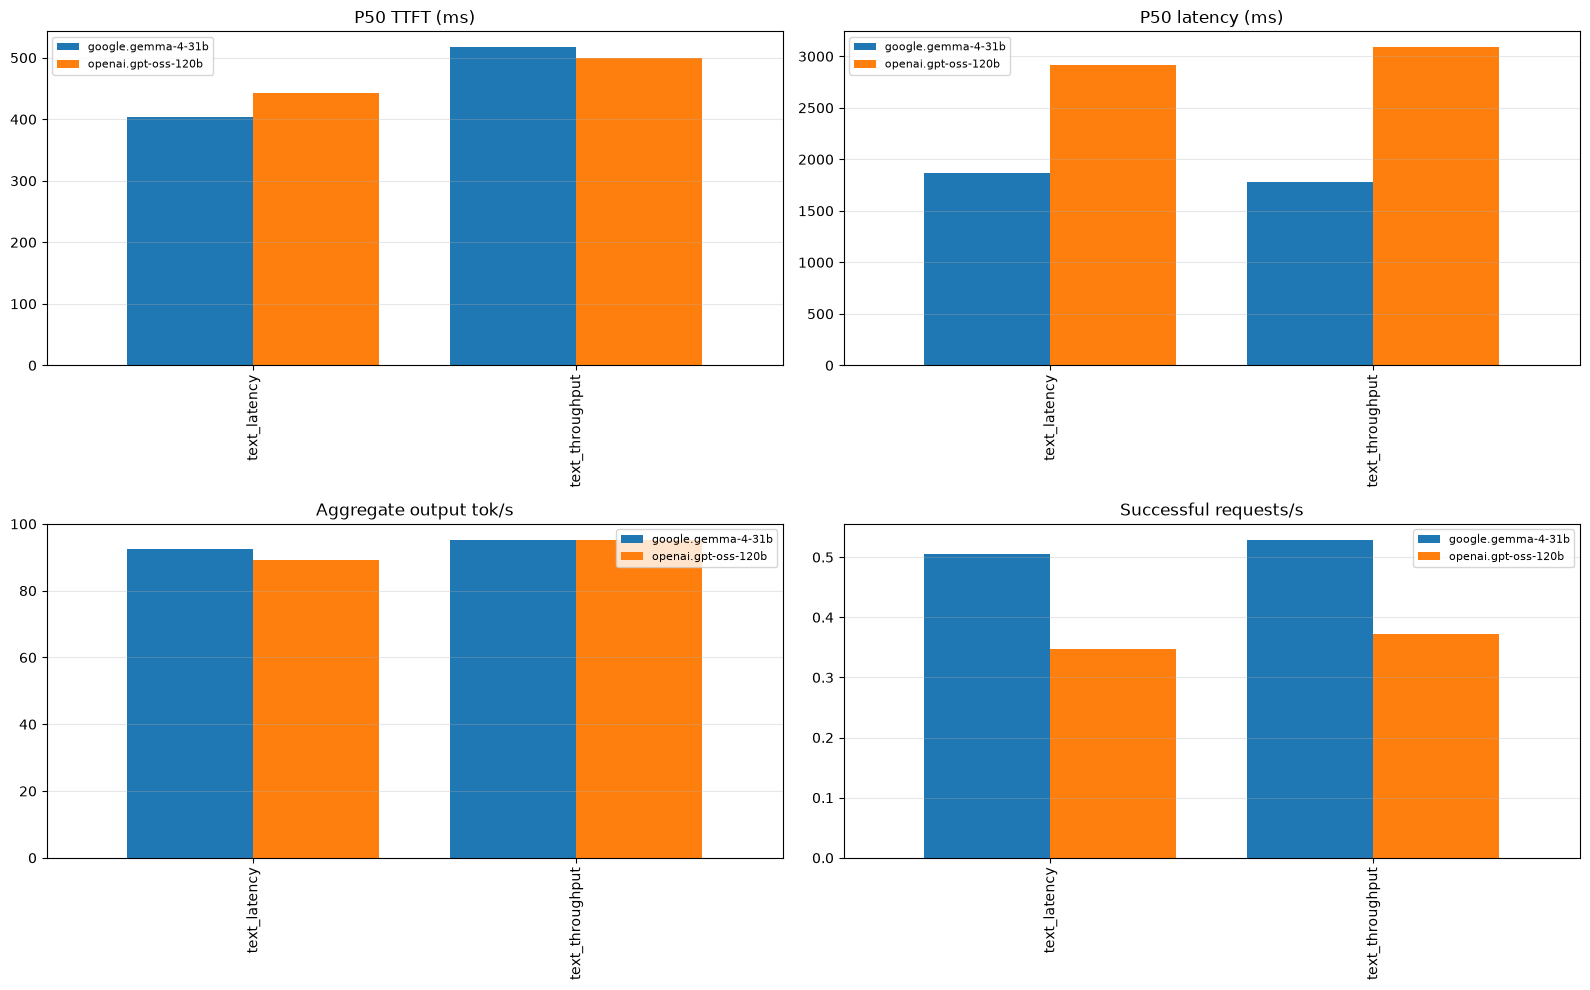

In [19]:
import matplotlib.pyplot as plt

if perf_summary.empty:
    print("No performance summary rows to plot.")
else:
    metrics = [
        ("ttft_p50_ms", "P50 TTFT (ms)"),
        ("latency_p50_ms", "P50 latency (ms)"),
        ("aggregate_output_tps", "Aggregate output tok/s"),
        ("request_rps", "Successful requests/s"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    for ax, (metric, title) in zip(axes.ravel(), metrics):
        pivot = perf_summary.pivot_table(index="workload", columns="model", values=metric, aggfunc="mean")
        pivot.plot(kind="bar", ax=ax, width=0.78)
        ax.set_title(title)
        ax.set_xlabel("")
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## Request-Level Latency


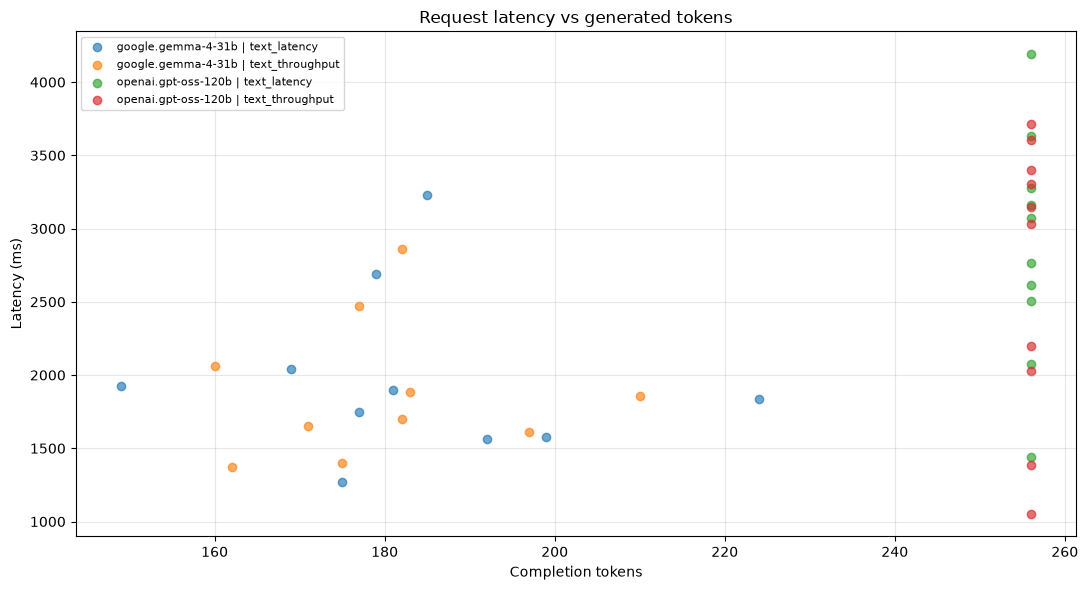

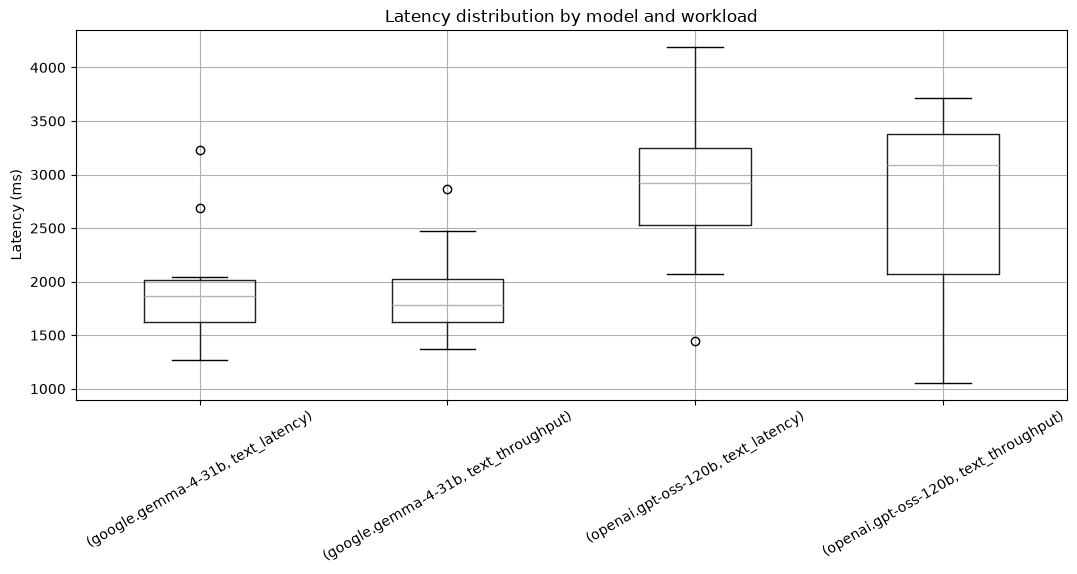

In [20]:
if perf.empty:
    print("No performance request rows to plot.")
else:
    ok_perf = perf[truthy(perf["ok"])].copy()
    if ok_perf.empty:
        print("No successful performance requests.")
    else:
        fig, ax = plt.subplots(figsize=(11, 6))
        for (model, workload), group in ok_perf.groupby(["model", "workload"]):
            ax.scatter(
                group["completion_tokens"],
                group["latency_ms"],
                alpha=0.65,
                s=36,
                label=f"{model} | {workload}",
            )
        ax.set_xlabel("Completion tokens")
        ax.set_ylabel("Latency (ms)")
        ax.set_title("Request latency vs generated tokens")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(11, 6))
        ok_perf.boxplot(column="latency_ms", by=["model", "workload"], ax=ax, rot=30)
        ax.set_title("Latency distribution by model and workload")
        ax.set_xlabel("")
        ax.set_ylabel("Latency (ms)")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()


## Accuracy Charts


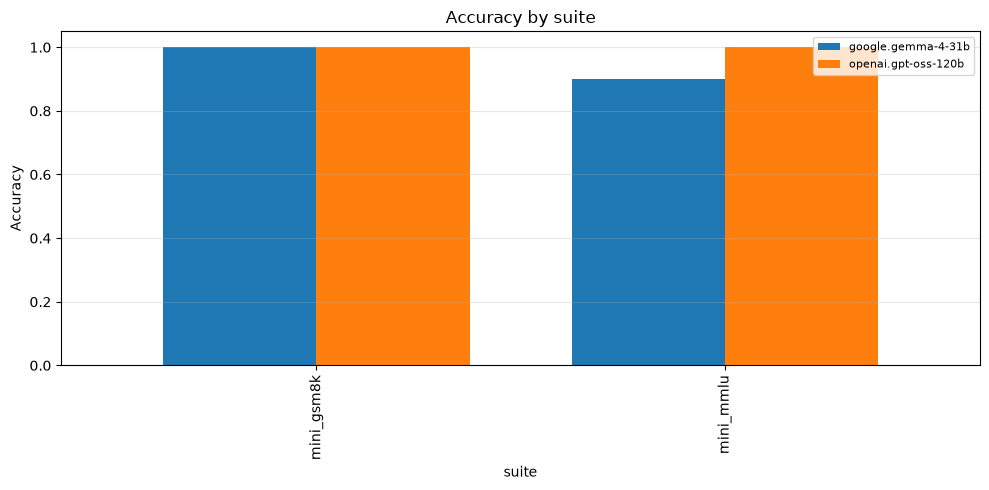

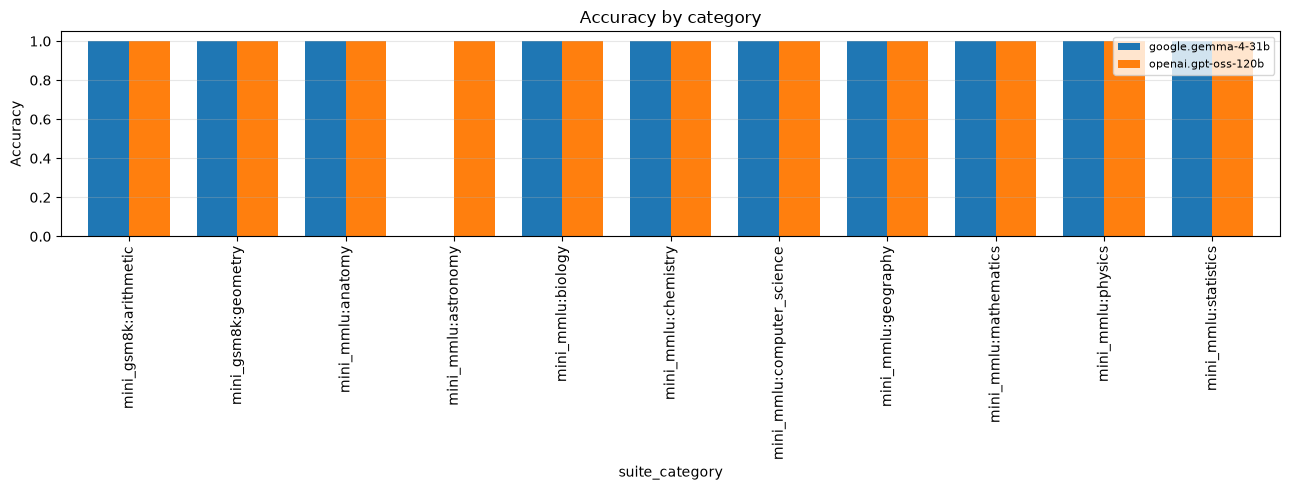

In [21]:
if acc_summary.empty:
    print("No accuracy summary rows to plot.")
else:
    suite_rows = acc_summary.copy()
    if "category" in suite_rows.columns:
        suite_rows = suite_rows[suite_rows["category"].isna()]
    if not suite_rows.empty:
        pivot = suite_rows.pivot_table(index="suite", columns="model", values="accuracy", aggfunc="mean")
        ax = pivot.plot(kind="bar", figsize=(10, 5), width=0.75)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Accuracy")
        ax.set_title("Accuracy by suite")
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

    if "category" in acc_summary.columns:
        category_rows = acc_summary[acc_summary["category"].notna()].copy()
        if not category_rows.empty:
            category_rows["suite_category"] = category_rows["suite"].astype(str) + ":" + category_rows["category"].astype(str)
            pivot = category_rows.pivot_table(index="suite_category", columns="model", values="accuracy", aggfunc="mean")
            ax = pivot.plot(kind="bar", figsize=(13, 5), width=0.75)
            ax.set_ylim(0, 1.05)
            ax.set_ylabel("Accuracy")
            ax.set_title("Accuracy by category")
            ax.grid(True, axis="y", alpha=0.3)
            ax.legend(fontsize=8)
            plt.tight_layout()
            plt.show()


## Accuracy Error Inspection


In [22]:
if accuracy.empty:
    print("No accuracy rows.")
else:
    wrong = accuracy[truthy(accuracy["ok"]) & ~truthy(accuracy["correct"])]
    display(wrong[["model", "suite", "item_id", "category", "expected", "prediction", "output_text"]])


,model,suite,item_id,category,expected,prediction,output_text
16,google.gemma-4-31b,mini_mmlu,mmlu_009,astronomy,B,NaN,our<unused6226><unused6226><unused6226><unuse...


## Headless CLI Equivalent

The notebook calls the same runner as the command line. A few equivalent examples:

```bash
python scripts/mantle_gemma_benchmark.py --profile smoke --list-models
python scripts/mantle_gemma_benchmark.py --profile sglang-text --num-prompts 32 --max-concurrency 8 --input-tokens 512 --output-tokens 256
python scripts/mantle_gemma_benchmark.py --profile sglang-full --accuracy-jsonl results/mantle_gemma/standard_accuracy_sample.jsonl
```
